# Cross-Library HPO: XGBoost vs LightGBM vs CatBoost

**Docker image**: `ml4t-gpu`

**Chapter 12, Section 12.4**: Advanced Hyperparameter Tuning with Optuna

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 12_gradient_boosting/05_cross_library_hpo.py
> ```


## Purpose
Optuna-based HPO for XGBoost, LightGBM, and CatBoost on the Chen-Pelger-Zhu
(2020) firm characteristics dataset. **Loss type is a hyperparameter**
within each library's study, treating the choice of MSE vs MAE as a tunable
decision rather than a fixed prior.

## Learning Objectives
- Tune XGBoost, LightGBM, and CatBoost with Optuna under a shared protocol
- Treat loss function selection as a first-class hyperparameter
- Compare best-valid and best-test IC after model reconstruction
- Diagnose which hyperparameters drive gains in noisy financial targets

**Prerequisites**: Requires the firm characteristics dataset and supporting
loaders from `data/__init__.py`.

## Key Concepts
- TPE with configurable warm-up trials for each library
- MedianPruner for early stopping of unpromising trials
- SQLite persistence for reproducibility
- Loss function as a categorical hyperparameter
- Hyperparameter importance analysis (including loss_type)

## Cross-References
- **Section 12.4**: GBM-specific tuning strategy, pruning
- **Chapter 20**: These results feed into the cross-model synthesis
- **Related**: `04_optuna_tuning` (ETF case study), `07_hpo_comparison` (grid vs Optuna)

## 1. Setup

In [1]:
"""Cross-Library HPO: tune XGBoost, LightGBM, and CatBoost with Optuna on financial data."""

# Import torch before ml4t.diagnostic. ml4t.diagnostic transitively dlopens
# the older system libcudart.so.12; loading torch first makes its bundled
# CUDA runtime win symbol resolution.
import warnings

import catboost as cb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import polars as pl
import torch  # noqa: F401
import xgboost as xgb
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

from data import load_firm_characteristics


def cross_sectional_ic_mean(y_true, y_pred, dates, entities):
    pred_df = pl.DataFrame({"timestamp": dates, "entity": entities, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "entity": entities, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="entity",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
N_TRIALS = 50
N_WARMUP_TRIALS = 5
EARLY_STOPPING_ROUNDS = 50
N_LIBRARIES = 0  # 0 = all libraries, 1-3 = first N only
SEED = 42

In [3]:
set_global_seeds(SEED)

In [4]:
OUTPUT_DIR = get_output_dir(12, "us_firm_characteristics")

### Device Detection

XGBoost and CatBoost support GPU acceleration. We detect availability
at startup rather than hardcoding `device="cuda"`.

In [5]:
GPU_AVAILABLE = torch.cuda.is_available()

XGB_DEVICE = "cuda" if GPU_AVAILABLE else "cpu"
CB_TASK_TYPE = "GPU" if GPU_AVAILABLE else "CPU"
print(f"GPU available: {GPU_AVAILABLE} (XGB: {XGB_DEVICE}, CatBoost: {CB_TASK_TYPE})")

GPU available: True (XGB: cuda, CatBoost: GPU)


> **Reproducibility.** This search runs on a GPU for speed. GPU training is not
> bitwise reproducible: fixed seeds pin each model's random choices but not the
> order in which parallel hardware sums floating-point values, so the best
> configurations and IC values here are empirically stable across reruns rather
> than identical to the last decimal. For runs that must reproduce exactly, train
> on CPU with deterministic settings; `02_gbm_comparison` measures the
> GPU-versus-CPU prediction gap and gives the deterministic CPU recipe in full.

## 2. Load Academic Dataset

In [6]:
train_df = load_firm_characteristics(split="train")
valid_df = load_firm_characteristics(split="valid")
test_df = load_firm_characteristics(split="test")

print(
    f"Train: {len(train_df):,} (1967-1989), Valid: {len(valid_df):,} (1990-1999), Test: {len(test_df):,} (2000-2016)"
)

Train: 414,025 (1967-1989), Valid: 307,094 (1990-1999), Test: 497,436 (2000-2016)


In [7]:
feature_cols = [c for c in train_df.columns if c not in ["timestamp", "ret", "split"]]

X_train = train_df.select(feature_cols).to_numpy()
y_train = train_df["ret"].to_numpy()
X_valid = valid_df.select(feature_cols).to_numpy()
y_valid = valid_df["ret"].to_numpy()
X_test = test_df.select(feature_cols).to_numpy()
y_test = test_df["ret"].to_numpy()

# Per-date timestamps for cross-sectional IC. Firm IDs are anonymized in this
# dataset, so synthesize per-row entity IDs to make the cross-section join 1:1.
dates_valid = valid_df["timestamp"].to_numpy()
entities_valid = np.arange(len(y_valid))
dates_test = test_df["timestamp"].to_numpy()
entities_test = np.arange(len(y_test))

print(f"Features: {len(feature_cols)}, Shapes: {X_train.shape} / {X_valid.shape} / {X_test.shape}")

Features: 46, Shapes: (414025, 46) / (307094, 46) / (497436, 46)


## 3. Study Configuration

SQLite storage enables persistent studies. The database-backed approach
also supports parallel workers in production settings (PostgreSQL/MySQL
for true parallelism; SQLite for single-worker reproducibility).

Persistence has one sharp edge worth flagging: with `load_if_exists=True`,
re-running the notebook against an existing database *appends* new trials to
the old study rather than starting over, so the trial counts and best configs
would creep upward on every execution. To keep the results reproducible we
delete any prior database at the top of the run, so a fresh execution always
optimizes exactly `N_TRIALS` seeded trials per library.

In [8]:
STORAGE_PATH = f"sqlite:///{OUTPUT_DIR / 'hpo_studies.db'}"

# Reset persisted studies so each full run reproduces from scratch (see above).
_db_file = OUTPUT_DIR / "hpo_studies.db"
if _db_file.exists():
    _db_file.unlink()


def create_study(study_name: str, direction: str = "maximize") -> optuna.Study:
    """Create or load an Optuna study with TPE sampler and pruning."""
    return optuna.create_study(
        study_name=study_name,
        storage=STORAGE_PATH,
        load_if_exists=True,
        direction=direction,
        sampler=TPESampler(seed=SEED, n_startup_trials=N_WARMUP_TRIALS),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10),
    )


all_results = []

## 4. Objective Functions with Loss as Hyperparameter

Each library has one study where `loss_type` (MSE/MAE) is a categorical
parameter. This treats the loss function as a tunable decision rather than
a fixed choice.

In [9]:
def make_xgboost_objective():
    """Factory for XGBoost objective with loss as hyperparameter."""

    def objective(trial: optuna.Trial) -> float:
        loss_type = trial.suggest_categorical("loss_type", ["mse", "mae"])
        xgb_obj = "reg:squarederror" if loss_type == "mse" else "reg:absoluteerror"

        params = {
            "objective": xgb_obj,
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 300),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 100.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 100.0, log=True),
            "tree_method": "hist",
            "device": XGB_DEVICE,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "random_state": SEED,
            "verbosity": 0,
        }
        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
        return cross_sectional_ic_mean(y_valid, model.predict(X_valid), dates_valid, entities_valid)

    return objective

### LightGBM Objective Factory

In [10]:
def make_lightgbm_objective():
    """Factory for LightGBM objective with loss as hyperparameter."""

    def objective(trial: optuna.Trial) -> float:
        loss_type = trial.suggest_categorical("loss_type", ["mse", "mae"])
        lgb_obj = "regression" if loss_type == "mse" else "mae"

        params = {
            "objective": lgb_obj,
            "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
            "max_depth": trial.suggest_int("max_depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 8, 128),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 300),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-5, 100.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 100.0, log=True),
            "random_state": SEED,
            "verbose": -1,
        }
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
        return cross_sectional_ic_mean(y_valid, model.predict(X_valid), dates_valid, entities_valid)

    return objective

### CatBoost Objective Factory

In [11]:
def make_catboost_objective():
    """Factory for CatBoost objective with loss as hyperparameter."""

    def objective(trial: optuna.Trial) -> float:
        loss_type = trial.suggest_categorical("loss_type", ["mse", "mae"])
        cb_loss = "RMSE" if loss_type == "mse" else "MAE"

        params = {
            "loss_function": cb_loss,
            "iterations": trial.suggest_int("iterations", 100, 1000),
            "depth": trial.suggest_int("depth", 2, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-5, 100.0, log=True),
            "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "task_type": CB_TASK_TYPE,
            "random_seed": SEED,
            "verbose": False,
            "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
            "train_dir": "/tmp/catboost_info",
        }
        model = cb.CatBoostRegressor(**params)
        model.fit(X_train, y_train, eval_set=(X_valid, y_valid), verbose=False)
        return cross_sectional_ic_mean(y_valid, model.predict(X_valid), dates_valid, entities_valid)

    return objective

## 5. Model Building Helper

Shared function to reconstruct and evaluate models from Optuna trial
parameters. This eliminates the ~80 lines of duplicated model-building
code that would otherwise appear in the optimization and per-loss sections.

In [12]:
def build_model(lib_code, params):
    """Build model instance from Optuna params and selected library."""
    loss_type = params.get("loss_type", "mse")
    eval_params = {k: v for k, v in params.items() if k not in ["loss_type"]}

    if lib_code == "xgb":
        xgb_obj = "reg:squarederror" if loss_type == "mse" else "reg:absoluteerror"
        return xgb.XGBRegressor(
            **eval_params,
            objective=xgb_obj,
            tree_method="hist",
            device=XGB_DEVICE,
            early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            random_state=SEED,
            verbosity=0,
        )

    if lib_code == "lgb":
        lgb_obj = "regression" if loss_type == "mse" else "mae"
        return lgb.LGBMRegressor(
            **eval_params,
            objective=lgb_obj,
            random_state=SEED,
            verbose=-1,
        )

    cb_loss = "RMSE" if loss_type == "mse" else "MAE"
    return cb.CatBoostRegressor(
        **eval_params,
        loss_function=cb_loss,
        task_type=CB_TASK_TYPE,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_seed=SEED,
        verbose=False,
        train_dir="/tmp/catboost_info",
    )

### Evaluate Best-Config Model

In [13]:
def build_and_evaluate(
    lib_code,
    params,
    X_tr,
    y_tr,
    X_va,
    y_va,
    X_te,
    y_te,
    dates_va,
    entities_va,
    dates_te,
    entities_te,
):
    """Fit model from Optuna params and return (model, valid_ic, test_ic)."""
    model = build_model(lib_code, params)
    if lib_code == "xgb":
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    elif lib_code == "lgb":
        model.fit(
            X_tr,
            y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
    else:
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=False)

    valid_ic = cross_sectional_ic_mean(y_va, model.predict(X_va), dates_va, entities_va)
    test_ic = cross_sectional_ic_mean(y_te, model.predict(X_te), dates_te, entities_te)
    return model, valid_ic, test_ic

## 6. Run Optimization

In [14]:
LIBRARY_CONFIGS = [
    ("XGBoost", "academic_xgboost", make_xgboost_objective(), "xgb"),
    ("LightGBM", "academic_lightgbm", make_lightgbm_objective(), "lgb"),
    ("CatBoost", "academic_catboost", make_catboost_objective(), "cb"),
]
if N_LIBRARIES > 0:
    LIBRARY_CONFIGS = LIBRARY_CONFIGS[:N_LIBRARIES]

for lib_name, study_name, objective, lib_code in LIBRARY_CONFIGS:
    print(f"\nOptimizing {lib_name} ({N_TRIALS} trials)...")

    study = create_study(study_name)
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    _, valid_ic, test_ic = build_and_evaluate(
        lib_code,
        study.best_params,
        X_train,
        y_train,
        X_valid,
        y_valid,
        X_test,
        y_test,
        dates_valid,
        entities_valid,
        dates_test,
        entities_test,
    )

    loss_type = study.best_params["loss_type"]
    print(f"  Best: Valid IC={valid_ic:.4f}, Test IC={test_ic:.4f}, Loss={loss_type.upper()}")

    all_results.append(
        {
            "model": lib_name,
            "library": lib_code.upper(),
            "loss_type": loss_type.upper(),
            "valid_ic": round(valid_ic, 4),
            "test_ic": round(test_ic, 4),
            "n_trials": len(study.trials),
        }
    )


Optimizing XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best: Valid IC=0.1099, Test IC=0.0787, Loss=MAE

Optimizing LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

  Best: Valid IC=0.1091, Test IC=0.0776, Loss=MAE

Optimizing CatBoost (50 trials)...


...

Default metric period is 5 because MAE is/are not implemented for GPU


Default metric period is 5 because MAE is/are not implemented for GPU


Default metric period is 5 because MAE is/are not implemented for GPU


Default metric period is 5 because MAE is/are not implemented for GPU


  Best: Valid IC=0.1093, Test IC=0.0773, Loss=MAE


## 7. Per-Loss Analysis

Extract the best MSE and best MAE configuration for each library to
assess whether loss function choice matters.

In [15]:
detailed_results = []

for lib_name, study_name, _, lib_code in LIBRARY_CONFIGS:
    study = optuna.load_study(study_name=study_name, storage=STORAGE_PATH)

    loss_results = {"mse": None, "mae": None}
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            lt = trial.params["loss_type"]
            if loss_results[lt] is None or trial.value > loss_results[lt]["valid_ic"]:
                loss_results[lt] = {"valid_ic": trial.value, "params": trial.params}

    for lt, info in loss_results.items():
        if info is None:
            continue

        _, valid_ic, test_ic = build_and_evaluate(
            lib_code,
            info["params"],
            X_train,
            y_train,
            X_valid,
            y_valid,
            X_test,
            y_test,
            dates_valid,
            entities_valid,
            dates_test,
            entities_test,
        )
        detailed_results.append(
            {
                "model": f"{lib_name}_{lt.upper()}",
                "library": lib_code.upper(),
                "loss_type": lt.upper(),
                "valid_ic": round(valid_ic, 4),
                "test_ic": round(test_ic, 4),
            }
        )

Default metric period is 5 because MAE is/are not implemented for GPU


## 8. Results Summary

In [16]:
results_df = pl.DataFrame(all_results).sort("test_ic", descending=True)
results_df.select(["model", "loss_type", "valid_ic", "test_ic", "n_trials"])

model,loss_type,valid_ic,test_ic,n_trials
str,str,f64,f64,i64
"""XGBoost""","""MAE""",0.1099,0.0787,50
"""LightGBM""","""MAE""",0.1091,0.0776,50
"""CatBoost""","""MAE""",0.1093,0.0773,50


In [17]:
results_df.write_csv(OUTPUT_DIR / "hpo_gbm_results.csv")

In [18]:
detailed_df = pl.DataFrame(detailed_results).sort("test_ic", descending=True)
detailed_df.select(["model", "loss_type", "valid_ic", "test_ic"])

model,loss_type,valid_ic,test_ic
str,str,f64,f64
"""XGBoost_MAE""","""MAE""",0.1099,0.0787
"""LightGBM_MAE""","""MAE""",0.1091,0.0776
"""CatBoost_MAE""","""MAE""",0.1093,0.0773
"""LightGBM_MSE""","""MSE""",0.0973,0.0614
"""XGBoost_MSE""","""MSE""",0.098,0.0603
"""CatBoost_MSE""","""MSE""",0.0932,0.0593


In [19]:
detailed_df.write_csv(OUTPUT_DIR / "hpo_gbm_detailed.csv")

## 9. MSE vs MAE Comparison

In [20]:
loss_comparison = []
for lib in ["XGB", "LGB", "CB"]:
    lib_mse = detailed_df.filter((pl.col("library") == lib) & (pl.col("loss_type") == "MSE"))
    lib_mae = detailed_df.filter((pl.col("library") == lib) & (pl.col("loss_type") == "MAE"))
    if len(lib_mse) > 0 and len(lib_mae) > 0:
        mse_ic = lib_mse["test_ic"][0]
        mae_ic = lib_mae["test_ic"][0]
        loss_comparison.append(
            {
                "library": lib,
                "mse_test_ic": mse_ic,
                "mae_test_ic": mae_ic,
                "difference": round(mae_ic - mse_ic, 4),
                "loss_choice": "MAE" if mae_ic > mse_ic else "MSE",
            }
        )

loss_comparison_df = pl.DataFrame(loss_comparison)
loss_comparison_df

library,mse_test_ic,mae_test_ic,difference,loss_choice
str,f64,f64,f64,str
"""XGB""",0.0603,0.0787,0.0184,"""MAE"""
"""LGB""",0.0614,0.0776,0.0162,"""MAE"""
"""CB""",0.0593,0.0773,0.018,"""MAE"""


The grouped bars make the pattern unmistakable: for every library the MAE bar
clears the MSE bar on the held-out 2000–2016 test window.

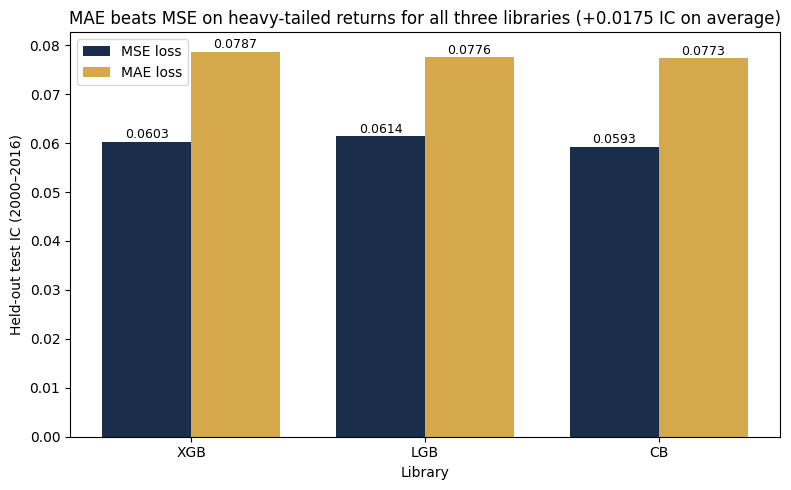

In [21]:
libs = loss_comparison_df["library"].to_list()
mse_ics = loss_comparison_df["mse_test_ic"].to_list()
mae_ics = loss_comparison_df["mae_test_ic"].to_list()

x = np.arange(len(libs))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 5))
bars_mse = ax.bar(x - width / 2, mse_ics, width, label="MSE loss", color=COLORS["slate"])
bars_mae = ax.bar(x + width / 2, mae_ics, width, label="MAE loss", color=COLORS["amber"])
for bars in (bars_mse, bars_mae):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0007,
            f"{bar.get_height():.4f}",
            ha="center",
            fontsize=9,
        )
ax.set_xticks(x)
ax.set_xticklabels(libs)
ax.set_xlabel("Library")
ax.set_ylabel("Held-out test IC (2000–2016)")
ax.legend()
mean_gain = loss_comparison_df["difference"].mean()
ax.set_title(
    f"MAE beats MSE on heavy-tailed returns for all three libraries (+{mean_gain:.4f} IC on average)"
)
plt.tight_layout()
plt.show()

**Interpretation**: On this academic dataset with heavy-tailed returns, the
choice between MSE and MAE materially affects IC. MAE is more robust to
outliers, which matters when the target distribution has fat tails. Including
loss type as a hyperparameter lets the optimizer discover this automatically
rather than fixing it by prior.

## 10. Hyperparameter Importance

In [22]:
importance_records = []

for lib_name, study_name, _, _ in LIBRARY_CONFIGS:
    try:
        study = optuna.load_study(study_name=study_name, storage=STORAGE_PATH)
        if len(study.trials) > 1:
            importance = optuna.importance.get_param_importances(study)
            for param, imp in list(importance.items())[:6]:
                importance_records.append(
                    {"model": lib_name, "param": param, "importance": round(imp, 4)}
                )
    except Exception as e:
        print(f"Could not analyze {study_name}: {e}")

importance_df = pl.DataFrame(importance_records)
importance_df

model,param,importance
str,str,f64
"""XGBoost""","""loss_type""",0.3838
"""XGBoost""","""learning_rate""",0.294
"""XGBoost""","""max_depth""",0.0963
"""XGBoost""","""n_estimators""",0.0909
"""XGBoost""","""min_child_weight""",0.0807
…,…,…
"""CatBoost""","""learning_rate""",0.1668
"""CatBoost""","""depth""",0.06
"""CatBoost""","""iterations""",0.0313


Ranking the fANOVA importances per library puts the loss-type decision at or
near the top of every panel: the categorical MSE/MAE switch explains more of
the validation-IC variance than any continuous hyperparameter.

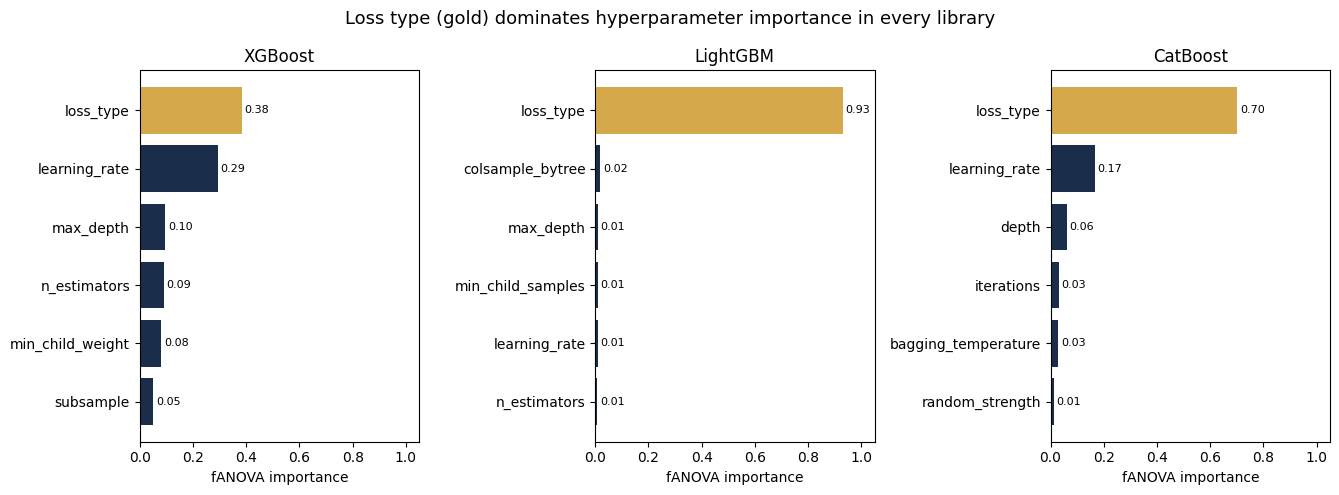

In [23]:
lib_order = [ln for ln, *_ in LIBRARY_CONFIGS]
fig, axes = plt.subplots(1, len(lib_order), figsize=(4.5 * len(lib_order), 5), sharex=False)
if len(lib_order) == 1:
    axes = [axes]

for ax, lib_name in zip(axes, lib_order, strict=False):
    sub = importance_df.filter(pl.col("model") == lib_name).sort("importance")
    params = sub["param"].to_list()
    imps = sub["importance"].to_list()
    bar_colors = [COLORS["amber"] if p == "loss_type" else COLORS["slate"] for p in params]
    ax.barh(params, imps, color=bar_colors)
    for i, imp in enumerate(imps):
        ax.text(imp + 0.01, i, f"{imp:.2f}", va="center", fontsize=8)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("fANOVA importance")
    ax.set_title(lib_name)

fig.suptitle(
    "Loss type (gold) dominates hyperparameter importance in every library",
    fontsize=13,
)
plt.tight_layout()
plt.show()

In [24]:
importance_df.write_csv(OUTPUT_DIR / "hpo_gbm_importance.csv")

## 11. Optimization History

In [25]:
history = {}
best_trials = {}
for lib_name, study_name, _, _ in LIBRARY_CONFIGS:
    study = optuna.load_study(study_name=study_name, storage=STORAGE_PATH)
    best_num = study.best_trial.number
    total = len(study.trials)
    best_trials[lib_name] = best_num

    loss_counts = {"mse": 0, "mae": 0}
    values = []
    for trial in study.trials:
        if trial.state == optuna.trial.TrialState.COMPLETE:
            loss_counts[trial.params["loss_type"]] += 1
        values.append(trial.value if trial.value is not None else np.nan)
    history[lib_name] = np.array(values, dtype=float)

    print(
        f"{lib_name}: best at trial #{best_num}/{total}, "
        f"loss={study.best_params['loss_type'].upper()}, "
        f"distribution: MSE={loss_counts['mse']}, MAE={loss_counts['mae']}"
    )

XGBoost: best at trial #43/50, loss=MAE, distribution: MSE=9, MAE=41
LightGBM: best at trial #44/50, loss=MAE, distribution: MSE=9, MAE=41
CatBoost: best at trial #46/50, loss=MAE, distribution: MSE=9, MAE=41


Tracking the best validation IC found so far against the trial index shows how
TPE keeps improving in discrete steps rather than settling on an early plateau.

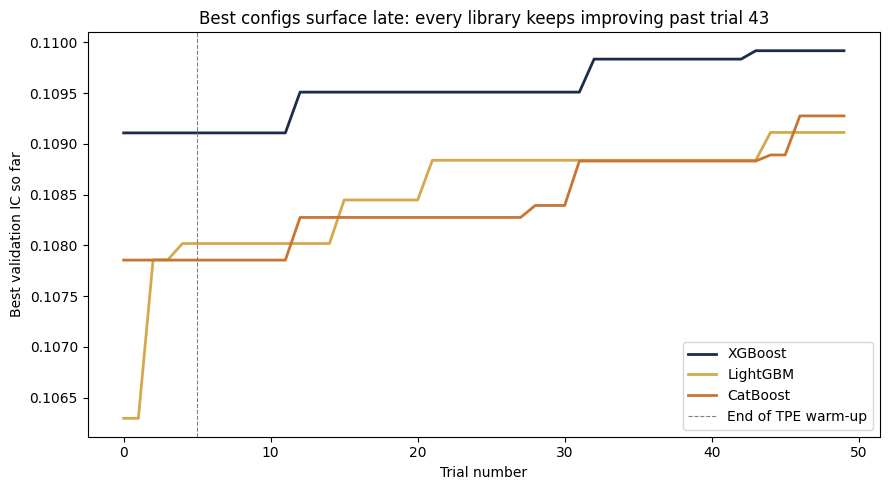

In [26]:
palette = [COLORS["slate"], COLORS["amber"], COLORS["copper"]]

fig, ax = plt.subplots(figsize=(9, 5))
for (lib_name, values), color in zip(history.items(), palette, strict=False):
    running_best = np.fmax.accumulate(np.nan_to_num(values, nan=-np.inf))
    running_best[running_best == -np.inf] = np.nan
    trials_axis = np.arange(len(values))
    ax.plot(trials_axis, running_best, color=color, linewidth=2, label=lib_name)

ax.axvline(N_WARMUP_TRIALS, linestyle="--", color="gray", linewidth=0.8, label="End of TPE warm-up")
ax.set_xlabel("Trial number")
ax.set_ylabel("Best validation IC so far")
ax.legend()
earliest_late_best = min(best_trials.values())
ax.set_title(
    f"Best configs surface late: every library keeps improving past trial {earliest_late_best}"
)
plt.tight_layout()
plt.show()

In [27]:
best_overall = results_df.row(0, named=True)
print(
    f"Best GBM: {best_overall['model']} ({best_overall['loss_type']}) IC={best_overall['test_ic']:.4f}"
)

Best GBM: XGBoost (MAE) IC=0.0787


## Key Takeaways

1. **Loss type matters as a hyperparameter.** Putting MSE and MAE in the search
   space lets Optuna discover the better loss for each library. Here the
   categorical loss switch is the single most important hyperparameter in every
   study, and MAE wins across all three libraries on these heavy-tailed returns.
2. **Early stopping tames a large search range.** Setting `n_estimators` up to
   1000 with an early-stopping patience of 50 lets the data pick the tree count
   instead of the search wasting compute on over-grown models.
3. **The library matters less than the tuning.** XGBoost, LightGBM, and CatBoost
   land within about 0.002 test IC of each other on the CPZ dataset, so a careful
   search over loss and depth buys more than switching implementations.
4. **These GBM results connect to Chapter 20.** The per-library, per-loss IC
   values illustrate the kind of tuned tabular baselines the cross-model
   synthesis in Chapter 20 builds on.

**Next**: See `04_optuna_tuning` for the full Optuna workflow on the ETF case
study, including walk-forward HPO and pruning effectiveness.